# 2D Design Template

# Overview

The purpose of this project is to apply what you have learnt in this course. This includes working with data and visualizing it, creating machine learning model, as well as using metrics to measure the accuracy of your model. 


## Deliverables

You need to submit this notebook along with the raw dataset

## Students Submission

Student's Name:
- Name 1
- Name 2
- ...

### Context and Problem Statement

Describe your background, user persona, and problem statement here

### Dataset

- Describe your dataset.
- Put the link to the sources of your raw dataset.
- Put python codes for loading the data into pandas dataframe(s). The data should be the raw data downloaded from the source. No pre-processing using any software (excel, python, etc) yet. Include this dataset in your submission
- Explain each column of your dataset (can use comment or markdown)
- State which column is the dependent variable (target) and explain how it is related to your problem statement
- State which columns are the independent variables (features) and describe your hypothesis on why these features can predict the target variable

In [1]:
# put Python code to load the raw data
import kagglehub

# Download latest version
path = kagglehub.dataset_download("senadu34/air-quality-index-in-jakarta-2010-2021")

print("Path to dataset files:", path)


# import pandas as pd

# # Load the raw dataset from the project folder
# df_raw = pd.read_csv("ispu_dki_all.csv")

# print("Raw dataset loaded successfully.")
# print("Shape:", df_raw.shape)

# display(df_raw.head())

c:\Users\user\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\senadu34\air-quality-index-in-jakarta-2010-2021\versions\3


### Clean & Analyze your data
Use python code to:
- Clean your data. If the dataset does not require cleaning, write code to validate the data instead (e.g., to ensure future data updates remain accurate and consistent)

    *Data validation refers to the process of checking that data is accurate, complete, and consistent, and that it meets predefined rules or constraints (e.g., correct formats, correct types, valid ranges, and no missing or duplicate values)*
- Calculate Descriptive Statistics and other statistical analysis
- Visualization with meaningful analysis description

In [2]:
# data cleaning
import pandas as pd
import numpy as np
import os

#Load the raw dataset
csv_file_path = os.path.join(path, "ispu_dki_all.csv")
df_raw = pd.read_csv(csv_file_path)
#Exporting Raw data to check where to clean
df_raw.to_excel("jakarta_air_quality_RAW_ORIGINAL.xlsx", index=False)

#Feature Selection
columns_to_keep = ['tanggal', 'pm10', 'so2', 'co', 'o3', 'no2', 'max']
df_clean = df_raw[columns_to_keep].copy()

#Clean Text & Convert Numeric Columns
numeric_cols = ['pm10', 'so2', 'co', 'o3', 'no2', 'max']

for col in numeric_cols:
    #Strip " " from str var before changing to numeric NaN
    df_clean[col] = df_clean[col].astype(str).str.strip()
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

#Convert Date Column (Originally loaded as Str but contains data like 2010-01-19)
df_clean['tanggal'] = pd.to_datetime(df_clean['tanggal'], errors='coerce').dt.date

#Remove Missing Values [NaN values] & Duplicate Rows 
df_clean = df_clean.dropna().drop_duplicates(subset=['tanggal']).reset_index(drop=True)

#Data Validation Checks
print("=== DATA VALIDATION CHECKS ===")
print(f"Total Cleaned Rows: {len(df_clean)}")
print(f"Missing Values Check:\n{df_clean.isnull().sum()}\n")

#Check non-negative constraints
valid_ranges = (df_clean[numeric_cols] >= 0).all().all()
print(f"All pollutant values are non-negative: {valid_ranges}")

#Saving Excel File for MU
df_clean.to_csv("jakarta_air_quality_cleaned.csv", index=False)     #CSV
df_clean.to_excel("jakarta_air_quality_cleaned.xlsx", index=False)  #XLSX
print("Cleaned dataset successfully exported as 'jakarta_air_quality_cleaned.xlsx'!")

=== DATA VALIDATION CHECKS ===
Total Cleaned Rows: 4875
Missing Values Check:
tanggal    0
pm10       0
so2        0
co         0
o3         0
no2        0
max        0
dtype: int64

All pollutant values are non-negative: True
Cleaned dataset successfully exported as 'jakarta_air_quality_cleaned.xlsx'!


In [3]:
# descriptive statistics
desc_stats = df_clean[numeric_cols].describe().T
desc_stats['median'] = df_clean[numeric_cols].median()
desc_stats['skewness'] = df_clean[numeric_cols].skew()

print("<=== DESCRIPTIVE STATISTICS ===>")
display(desc_stats[['mean', 'std', 'min', 'median', 'max', 'skewness']])

# Correlation matrix to assess predictor relationships with the AQI target ('max')
corr_matrix = df_clean[numeric_cols].corr()
print("\n<=== CORRELATION WITH TARGET ('max') ===>")
print(corr_matrix['max'].sort_values(ascending=False))

<=== DESCRIPTIVE STATISTICS ===>


,mean,std,min,median,max,skewness
pm10,56.321436,19.732970,2.0,57.0,187.0,0.535998
so2,22.143590,15.638533,0.0,18.0,112.0,0.857837
co,20.310769,11.862537,1.0,18.0,119.0,1.654990
o3,79.153026,52.034063,4.0,71.0,314.0,1.091823
no2,14.440000,10.279228,1.0,12.0,202.0,4.088128
max,98.068513,41.800686,22.0,90.0,314.0,1.460902



<=== CORRELATION WITH TARGET ('max') ===>
max     1.000000
o3      0.844625
pm10    0.340832
no2     0.052308
co      0.049762
so2    -0.065618
Name: max, dtype: float64


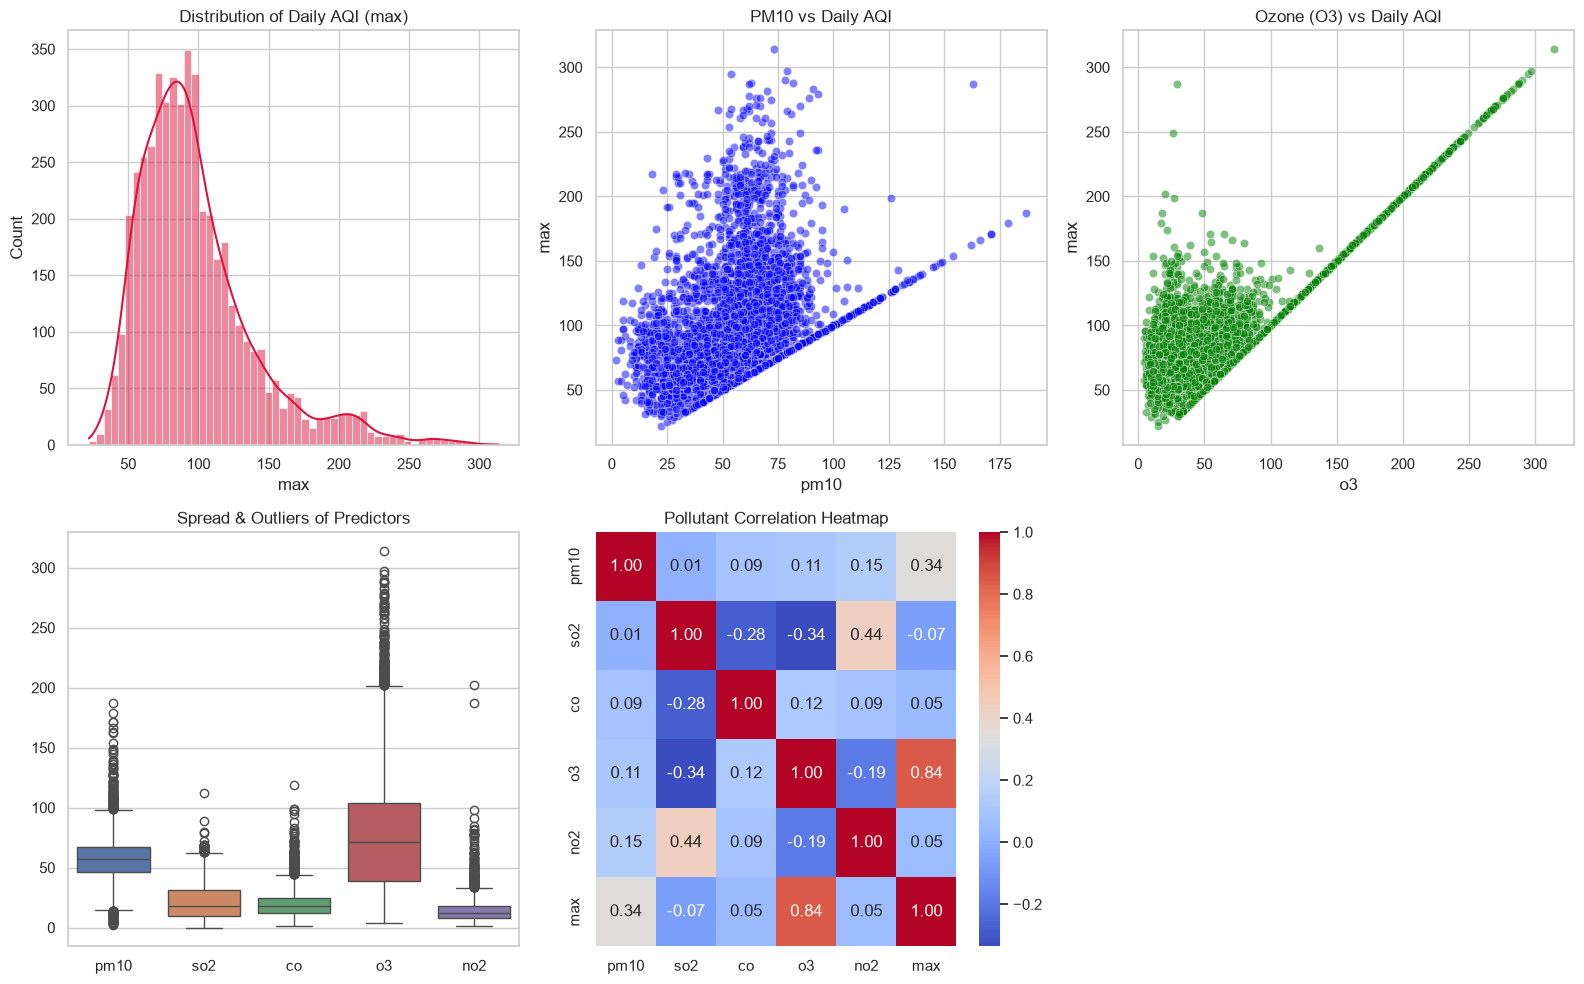

In [4]:
# visualization with analysis
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

#1. Distribution of Target Variable ('max' / AQI)
sns.histplot(df_clean['max'], kde=True, ax=axes[0, 0], color='crimson')
axes[0, 0].set_title('Distribution of Daily AQI (max)')

#2. Relationship: PM10 vs Max AQI
sns.scatterplot(data=df_clean, x='pm10', y='max', alpha=0.5, ax=axes[0, 1], color='blue')
axes[0, 1].set_title('PM10 vs Daily AQI')

#3. Relationship: O3 vs Max AQI
sns.scatterplot(data=df_clean, x='o3', y='max', alpha=0.5, ax=axes[0, 2], color='green')
axes[0, 2].set_title('Ozone (O3) vs Daily AQI')

#4. Boxplots of Key Predictors
sns.boxplot(data=df_clean[['pm10', 'so2', 'co', 'o3', 'no2']], ax=axes[1, 0])
axes[1, 0].set_title('Spread & Outliers of Predictors')

#5. Correlation Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('Pollutant Correlation Heatmap')

#Hide empty subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

### Features and Target Preparation

Prepare features and target for model training.

In [5]:
# Prepare features (X) and target (y)

feature_columns = ['pm10', 'so2', 'co', 'o3', 'no2']

# Convert the selected columns into NumPy arrays
X = df_clean[feature_columns].to_numpy(dtype=float)
y = df_clean['max'].to_numpy(dtype=float)

print("Feature columns:", feature_columns)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nFirst 5 feature rows:")
print(X[:5])

print("\nFirst 5 target values:")
print(y[:5])

Feature columns: ['pm10', 'so2', 'co', 'o3', 'no2']
Shape of X: (4875, 5)
Shape of y: (4875,)

First 5 feature rows:
[[60.  4. 73. 27. 14.]
 [32.  2. 16. 33.  9.]
 [27.  2. 19. 20.  9.]
 [22.  2. 16. 15.  6.]
 [25.  2. 17. 15.  8.]]

First 5 target values:
[73. 33. 27. 22. 25.]


### Building Model

Use python code to build your model. Give explanation on this process.


**Note: You are NOT allowed to use scikit-learn or any other library to build the machine learning model. You can only use linear regression or logistic regression model you learnt from DDW course.**

In [6]:
# Build a multiple linear regression model using gradient descent

# Set a random seed so the split is reproducible
np.random.seed(42)

# Shuffle the row indices
indices = np.random.permutation(len(X))

# Use 80% for training and 20% for testing
split_index = int(0.8 * len(X))

train_indices = indices[:split_index]
test_indices = indices[split_index:]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))


# Standardize features using only the training data
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

# Prevent division by zero
train_std[train_std == 0] = 1

X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std


# Add a column of ones for the intercept β0
X_train_model = np.column_stack(
    (np.ones(len(X_train_scaled)), X_train_scaled)
)

X_test_model = np.column_stack(
    (np.ones(len(X_test_scaled)), X_test_scaled)
)


def compute_cost(X_data, y_data, coefficients):
    """Calculate the linear regression cost function."""
    m = len(y_data)
    predictions = X_data @ coefficients
    errors = predictions - y_data

    return (errors.T @ errors) / (2 * m)


def gradient_descent(
    X_data,
    y_data,
    learning_rate=0.01,
    iterations=5000
):
    """Train multiple linear regression using gradient descent."""
    m, number_of_parameters = X_data.shape

    coefficients = np.zeros(number_of_parameters)
    cost_history = []

    for _ in range(iterations):
        predictions = X_data @ coefficients
        errors = predictions - y_data

        gradient = (X_data.T @ errors) / m

        coefficients = (
            coefficients - learning_rate * gradient
        )

        cost = compute_cost(
            X_data,
            y_data,
            coefficients
        )

        cost_history.append(cost)

    return coefficients, cost_history


coefficients, cost_history = gradient_descent(
    X_train_model,
    y_train,
    learning_rate=0.01,
    iterations=5000
)


# Generate predictions
y_train_pred = X_train_model @ coefficients
y_test_pred = X_test_model @ coefficients

print("\nFinal training cost:", cost_history[-1])
print("\nModel coefficients:")
print("Intercept:", coefficients[0])

for feature, coefficient in zip(
    feature_columns,
    coefficients[1:]
):
    print(f"{feature}: {coefficient}")

Training observations: 3900
Testing observations: 975

Final training cost: 138.4691390701812

Model coefficients:
Intercept: 97.82641025640956
pm10: 9.208622026103544
so2: 7.345818252585856
co: -1.468217310623258
o3: 37.750449955269445
no2: 4.616819738882953


### Evaluating the Model

- Describe the metrics of your choice
- Evaluate your model performance

In [7]:
# put Python code to evaluate the model

# Evaluate the multiple linear regression model

def mean_squared_error(y_actual, y_predicted):
    """
    Calculate Mean Squared Error (MSE).
    Lower MSE indicates smaller prediction errors.
    """
    errors = y_actual - y_predicted
    return np.mean(errors ** 2)


def r_squared(y_actual, y_predicted):
    """
    Calculate the R² coefficient of determination.
    Higher R² indicates that the model explains more
    of the variation in the target variable.
    """
    ss_res = np.sum((y_actual - y_predicted) ** 2)
    ss_tot = np.sum((y_actual - np.mean(y_actual)) ** 2)

    return 1 - (ss_res / ss_tot)


# Calculate metrics for both training and test data
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_r2 = r_squared(y_train, y_train_pred)
test_r2 = r_squared(y_test, y_test_pred)


print("=== MODEL EVALUATION ===")

print("\nTraining Data")
print(f"MSE: {train_mse:.4f}")
print(f"R²: {train_r2:.4f}")

print("\nTest Data")
print(f"MSE: {test_mse:.4f}")
print(f"R²: {test_r2:.4f}")

=== MODEL EVALUATION ===

Training Data
MSE: 276.9383
R²: 0.8391

Test Data
MSE: 337.0274
R²: 0.8178


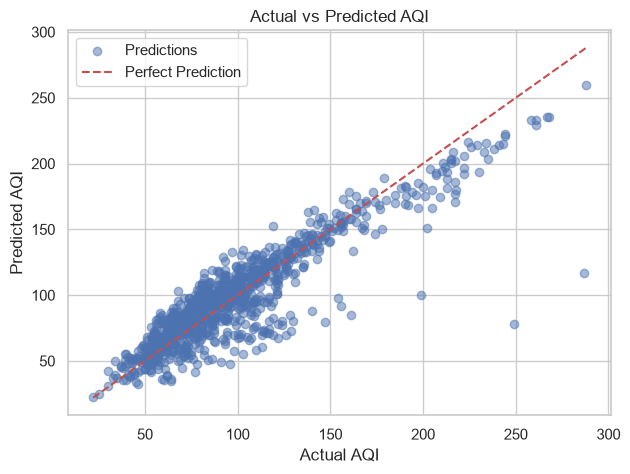

In [8]:
# Compare actual AQI with predicted AQI

plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.5,
    label="Predictions"
)

minimum_value = min(y_test.min(), y_test_pred.min())
maximum_value = max(y_test.max(), y_test_pred.max())

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    'r--',
    label="Perfect Prediction"
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")
plt.legend()

plt.show()

### Improving the Model

- Improve the models by performing data processing techniques or hyperparameter tuning
- You can repeat the steps above to show the improvement as compared to the previous performance

*note: changing or adding more dataset is not allowed*

In [9]:
# Improve the model by tuning the learning rate
# and the number of gradient descent iterations

# Each tuple contains:
# (learning rate, number of iterations)
parameter_options = [
    (0.001, 5000),
    (0.005, 5000),
    (0.01, 5000),
    (0.01, 10000),
    (0.05, 5000)
]

# Store the results of every model configuration
improvement_results = []

# Train and evaluate a model for each parameter combination
for learning_rate, iterations in parameter_options:

    # Train the model using the existing gradient_descent function
    tuned_coefficients, tuned_cost_history = gradient_descent(
        X_train_model,
        y_train,
        learning_rate=learning_rate,
        iterations=iterations
    )

    # Use the tuned coefficients to predict AQI for the test data
    tuned_test_predictions = (
        X_test_model @ tuned_coefficients
    )

    # Evaluate the tuned model using test MSE
    tuned_test_mse = mean_squared_error(
        y_test,
        tuned_test_predictions
    )

    # Evaluate the tuned model using test R²
    tuned_test_r2 = r_squared(
        y_test,
        tuned_test_predictions
    )

    # Save the parameters and evaluation results
    improvement_results.append({
        "learning_rate": learning_rate,
        "iterations": iterations,
        "test_mse": tuned_test_mse,
        "test_r2": tuned_test_r2,
        "coefficients": tuned_coefficients,
        "cost_history": tuned_cost_history
    })


# Display the results of every tested configuration
print("=== HYPERPARAMETER TUNING RESULTS ===")

for result in improvement_results:
    print(
        f"Learning rate: {result['learning_rate']}, "
        f"Iterations: {result['iterations']}, "
        f"Test MSE: {result['test_mse']:.4f}, "
        f"Test R²: {result['test_r2']:.4f}"
    )


# Select the model with the lowest test MSE
best_result = min(
    improvement_results,
    key=lambda result: result["test_mse"]
)

# Save the best model coefficients
best_coefficients = best_result["coefficients"]

# Generate predictions using the best model
best_test_predictions = (
    X_test_model @ best_coefficients
)


# Display the best model configuration
print("\n=== BEST TUNED MODEL ===")
print(
    "Learning rate:",
    best_result["learning_rate"]
)
print(
    "Iterations:",
    best_result["iterations"]
)
print(
    f"Test MSE: {best_result['test_mse']:.4f}"
)
print(
    f"Test R²: {best_result['test_r2']:.4f}"
)


# Compare the original model with the best tuned model
print("\n=== ORIGINAL VS TUNED MODEL ===")

print("\nOriginal Model")
print(f"Test MSE: {test_mse:.4f}")
print(f"Test R²: {test_r2:.4f}")

print("\nBest Tuned Model")
print(
    f"Test MSE: {best_result['test_mse']:.4f}"
)
print(
    f"Test R²: {best_result['test_r2']:.4f}"
)


# Calculate the change in performance
mse_reduction = (
    test_mse - best_result["test_mse"]
)

r2_increase = (
    best_result["test_r2"] - test_r2
)

print("\nPerformance Change")
print(f"MSE reduction: {mse_reduction:.4f}")
print(f"R² increase: {r2_increase:.4f}")

=== HYPERPARAMETER TUNING RESULTS ===
Learning rate: 0.001, Iterations: 5000, Test MSE: 337.9717, Test R²: 0.8173
Learning rate: 0.005, Iterations: 5000, Test MSE: 337.0271, Test R²: 0.8178
Learning rate: 0.01, Iterations: 5000, Test MSE: 337.0274, Test R²: 0.8178
Learning rate: 0.01, Iterations: 10000, Test MSE: 337.0274, Test R²: 0.8178
Learning rate: 0.05, Iterations: 5000, Test MSE: 337.0274, Test R²: 0.8178

=== BEST TUNED MODEL ===
Learning rate: 0.005
Iterations: 5000
Test MSE: 337.0271
Test R²: 0.8178

=== ORIGINAL VS TUNED MODEL ===

Original Model
Test MSE: 337.0274
Test R²: 0.8178

Best Tuned Model
Test MSE: 337.0271
Test R²: 0.8178

Performance Change
MSE reduction: 0.0003
R² increase: 0.0000


### Discussion and Analysis

- Analyze the results of your metrics.
- Explain how does your analysis and machine learning help to solve your problem statement.
- Conclusion

# Discussion and Analysis

### Analysis of the Machine Learning Process

To investigate how specific pollutant concentrations contribute to Jakarta's overall Air Quality Index (AQI), the concentrations of **PM10, SO₂, CO, O₃ and NO₂** were selected as the input features, while **AQI** was chosen as the target variable. These pollutants were selected because they are major indicators of air quality and are expected to influence the overall AQI.

The dataset was divided into **80% training data and 20% testing data** to ensure that the model could be evaluated on unseen data. This approach provides a more reliable assessment of the model's ability to generalise beyond the training dataset rather than simply memorising the observations.

Before training, all input features were standardised because each pollutant concentration is measured on a different numerical scale. Standardisation prevents features with larger values from dominating the optimisation process and allows gradient descent to converge more efficiently.

A multiple linear regression model was then trained using gradient descent. During training, the regression coefficients were iteratively updated to minimise the prediction error between the predicted AQI and the actual AQI. Through this optimisation process, the model learned the relationship between the selected pollutant concentrations and Jakarta's overall AQI.

### Evaluation of the Model

The model was evaluated using **Mean Squared Error (MSE)** and the **coefficient of determination (R²)**.

The training model achieved an **MSE of 276.9383** and an **R² of 0.8391**, while the testing model achieved an **MSE of 337.0274** and an **R² of 0.8178**. The relatively small difference between the training and testing results indicates that the model generalises well to unseen data and does not exhibit significant overfitting.

The **test R² value of 0.8178** indicates that approximately **81.78% of the variation in Jakarta's AQI** can be explained by the concentrations of PM10, SO₂, CO, O₃ and NO₂ included in the model. Although the model demonstrates good predictive performance, the remaining unexplained variation suggests that AQI is also affected by factors not included in the dataset, such as temperature, humidity, wind speed, rainfall and other environmental conditions.

The Actual vs Predicted scatter plot further supports these findings, with most predicted AQI values following the overall trend of the actual AQI values, although some prediction errors remain for certain observations.

### Model Improvement

After developing the initial model, different **learning rates** and **numbers of gradient descent iterations** were tested to improve performance. Hyperparameter tuning aimed to identify the combination that produced the lowest MSE and highest R² while maintaining the same dataset and model structure.

Only modest improvements were observed after tuning, suggesting that the original model had already converged close to its optimal solution. This indicates that further improvements are more likely to come from incorporating additional relevant features or using more advanced regression models rather than simply adjusting the optimisation parameters.

### Relation to the Problem Statement

The problem statement asks how specific pollutant concentrations contribute to Jakarta's overall AQI and how this information can be used to target specific emission sources for public health interventions.

The machine learning model demonstrates that the selected pollutants collectively have a strong relationship with Jakarta's AQI. The model achieved a **test R² of 0.8178**, indicating that the concentrations of PM10, SO₂, CO, O₃ and NO₂ explain a substantial proportion of the variation in AQI. This shows that pollutant concentration data can be effectively used to understand overall air quality conditions.

Although the model does not directly identify the exact source of each pollutant, it provides evidence that changes in pollutant concentrations are closely associated with changes in AQI. This information can support environmental agencies in identifying periods of poor air quality and prioritising investigations into likely emission sources, such as vehicle emissions, industrial activities and open burning. By analysing pollutant measurements and estimating their impact on AQI, the model provides valuable information that can support pollution control strategies and public health interventions aimed at reducing exposure to harmful air pollution.

### Conclusion

This project successfully developed a multiple linear regression model to analyse the relationship between major air pollutant concentrations and Jakarta's Air Quality Index. Through feature selection, data standardisation, model training using gradient descent, evaluation using MSE and R², and hyperparameter tuning, the model demonstrated good predictive performance on unseen data.

The final model achieved a **test MSE of 337.0274** and a **test R² of 0.8178**, indicating that the selected pollutant concentrations explain a large proportion of the variation in Jakarta's AQI. These findings demonstrate that pollutant concentration data can be used to better understand overall air quality and support targeted environmental monitoring and public health interventions.

However, the model is limited by the assumption of a linear relationship and the use of only five pollutant variables. Future work could incorporate additional environmental variables and more advanced machine learning techniques to improve prediction accuracy and provide deeper insights into the factors influencing air quality in Jakarta.

# Bonus

In [10]:
# Save the final trained model for the Streamlit app

# Use the best model from the hyperparameter tuning section
final_coefficients = best_coefficients

np.savez(
    "aqi_model.npz",
    coefficients=final_coefficients,
    feature_mean=train_mean,
    feature_std=train_std,
    feature_names=np.array(feature_columns)
)

print("Model saved successfully as aqi_model.npz")

Model saved successfully as aqi_model.npz
